### Import Required Dependencies

In [44]:
# --- Imports ---
import pandas as pd
import numpy as np
import warnings
import logging
import matplotlib.pyplot as plt
import seaborn as sns
import re
import sys
from functools import reduce



from pathlib import Path
from functools import reduce
from sklearn.preprocessing import MinMaxScaler
from collections import Counter

# --- Setup ---
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')

# --- Paths ---
data_dir = Path("data")
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

log_dir = Path("logs")
log_dir.mkdir(exist_ok=True)

image_dir = Path("outputs/images")
image_dir.mkdir(parents=True, exist_ok=True)

# Clear existing handlers
logging.getLogger().handlers.clear()

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler(log_dir / "project.log", mode='w', encoding='utf-8'),
        logging.StreamHandler(sys.stdout)
    ]
)


print("Environment ready. Paths and logging configured.")



Environment ready. Paths and logging configured.


# Section 2 Load and Process Dataset (national and Arkansas)

## Section 2A: Load utility functions

In [40]:
# Section 2A: Load utility functions and national datasets ----

# Import custom utility functions
from utils import (
    standardize_column_names,
    extract_key_indicators,
    filter_to_county_level,
    log_duplicate_attributes,
    clean_and_extract_year,
    nca_counties
)

data_dir = Path("data")
complete_dir = data_dir / "complete_sets"

complete_files = {
    "edu": "Education2023.csv",
    "pop": "PopulationEstimates.csv",
    "poverty": "Poverty2023.csv",
    "unemp": "Unemployment2023.csv"
}

# Load, clean, and extract year from each dataset
complete_data = {}

for key, filename in complete_files.items():
    path = complete_dir / filename
    try:
        df = pd.read_csv(path, encoding='cp1252')
        df = standardize_column_names(df)
        logging.info(f" {key} columns after cleaning: {df.columns.tolist()}")
        df = filter_to_county_level(df)
        df = clean_and_extract_year(df)

        # Rename fields if necessary
        df.rename(columns={'area_name': 'county'}, inplace=True)

        log_duplicate_attributes(df, key)
        complete_data[key] = df
        logging.info(f"Loaded {filename}: {df.shape[0]} rows")

    except Exception as e:
        logging.error(f" Failed to load {filename}: {e}")


# Confirmation message
logging.info("Utility functions from utils.py loaded successfully.")


2025-07-09 17:03:15,324 [INFO]  edu columns after cleaning: ['ïfips_code', 'state', 'area_name', 'attribute', 'value']
2025-07-09 17:03:15,818 [WARNING] edu has duplicate county-attribute pairs.
2025-07-09 17:03:15,819 [INFO] Loaded Education2023.csv: 169245 rows
2025-07-09 17:03:15,892 [INFO]  pop columns after cleaning: ['fipstxt', 'state', 'area_name', 'attribute', 'value']
2025-07-09 17:03:16,306 [WARNING] pop has duplicate county-attribute pairs.
2025-07-09 17:03:16,307 [INFO] Loaded PopulationEstimates.csv: 205108 rows
2025-07-09 17:03:16,337 [INFO]  poverty columns after cleaning: ['ïfips_code', 'state', 'area_name', 'attribute', 'value']
2025-07-09 17:03:16,502 [WARNING] poverty has duplicate county-attribute pairs.
2025-07-09 17:03:16,503 [INFO] Loaded Poverty2023.csv: 79961 rows
2025-07-09 17:03:16,642 [INFO]  unemp columns after cleaning: ['fips_code', 'state', 'area_name', 'attribute', 'value']
2025-07-09 17:03:17,262 [INFO] Loaded Unemployment2023.csv: 324636 rows
2025-07-

## Section 2B: Load and process national datasets

In [41]:
# Section 2B: Load and process national datasets

complete_dir = data_dir / "complete_sets"
complete_files = {
    "edu": "Education2023.csv",
    "pop": "PopulationEstimates.csv",
    "poverty": "Poverty2023.csv",
    "unemp": "Unemployment2023.csv"
}

state_lookup = None

# Choose your analysis year here
selected_year = '2023'

for key, filename in complete_files.items():
    path = complete_dir / filename
    try:
        # Load and standardize
        df = pd.read_csv(path, encoding='cp1252')
        df = standardize_column_names(df)
        df = filter_to_county_level(df)
        df.rename(columns={'area_name': 'county', 'fips_code': 'fips', 'fipstxt': 'fips'}, inplace=True)
        df['county'] = df['county'].str.strip().str.lower()

        # Extract year from attribute
        if 'attribute' in df.columns:
            df = clean_and_extract_year(df)

            # Only filter datasets where year tagging applies
            if key in ['pop', 'poverty', 'unemp']:
                df = df[df['attribute_year'] == selected_year]

        # Save state info once from education
        if key == 'edu':
            state_lookup = df[['county', 'state']].drop_duplicates().copy()
            state_lookup['county'] = state_lookup['county'].str.lower().str.strip()
            state_lookup['state'] = state_lookup['state'].str.upper().str.strip()

        log_duplicate_attributes(df, key)
        complete_data[key] = df
        logging.info(f" Loaded and processed {filename} with year filter: {selected_year if key != 'edu' else 'N/A'}")

    except Exception as e:
        logging.error(f" Failed to load {filename}: {e}")


2025-07-09 17:03:24,977 [WARNING] edu has duplicate county-attribute pairs.
2025-07-09 17:03:24,981 [INFO]  Loaded and processed Education2023.csv with year filter: N/A
2025-07-09 17:03:25,496 [WARNING] pop has duplicate county-attribute pairs.
2025-07-09 17:03:25,501 [INFO]  Loaded and processed PopulationEstimates.csv with year filter: 2023
2025-07-09 17:03:25,692 [WARNING] poverty has duplicate county-attribute pairs.
2025-07-09 17:03:25,694 [INFO]  Loaded and processed Poverty2023.csv with year filter: 2023
2025-07-09 17:03:26,565 [INFO]  Loaded and processed Unemployment2023.csv with year filter: 2023


### Section 2B.1 Determine most common year across all datasets

In [42]:
## Section 2B.1: Discover Common Year Across Datasets

def get_attribute_year_counts(df):
    """Counts how often each extracted attribute_year appears."""
    if 'attribute' in df.columns:
        df = clean_and_extract_year(df)
        return Counter(df['attribute_year'].dropna().astype(str))
    return {}

year_summary = {}

# Loop through each dataset and extract year counts
for key, df in complete_data.items():
    year_counts = get_attribute_year_counts(df)
    year_summary[key] = year_counts

# Display results
print("Year coverage by dataset:")
all_years = set()

for key, counts in year_summary.items():
    print(f"\n {key.upper()}:")
    if counts:
        for year, count in sorted(counts.items()):
            print(f"  {year}: {count}")
            all_years.add(year)
    else:
        print("  No attribute_year values found.")

# Find common years across all datasets that have year values
datasets_with_years = [set(c.keys()) for c in year_summary.values() if c]
common_years = set.intersection(*datasets_with_years) if datasets_with_years else set()



print("\n Common years across all datasets with usable attribute_year:", sorted(common_years))


Year coverage by dataset:

 EDU:
  1970: 25488
  1980: 26136
  1990: 26167
  2000: 26176
  2012: 26192
  2013: 6442
  2023: 29422
  2024: 3222

 POP:
  2023: 53619

 POVERTY:
  2023: 19223

 UNEMP:
  2023: 19326

 Common years across all datasets with usable attribute_year: ['2023']


## Section 2C: Subset Arkansas and NCA Counties

In [45]:
# Section 2C: Subset Arkansas and NCA Counties (No Full Merge)

# Define NCA counties (lowercase, cleaned)
nca_cleaned = [c.lower().strip() for c in nca_counties]

# Step 1: Function to filter, clean, and subset each dataset
def get_nca_subset(df, dataset_name):
    df = df.copy()
    df = df[df['state'].str.upper() == 'AR']
    df['county'] = (
        df['county']
        .str.replace(" county", "", regex=False)
        .str.replace(", ar", "", regex=False)
        .str.strip()
        .str.lower()
    )
    df_nca = df[df['county'].isin(nca_cleaned)].copy()
    logging.info(f"{dataset_name.upper()} → NCA rows: {df_nca.shape[0]}")
    return df_nca

# Step 2: Get cleaned NCA subsets
edu_nca = get_nca_subset(complete_data['edu'], 'edu')
poverty_nca = get_nca_subset(complete_data['poverty'], 'poverty')
unemp_nca = get_nca_subset(complete_data['unemp'], 'unemp')
pop_nca = get_nca_subset(complete_data['pop'], 'pop')

# Step 3: Pivot each to wide format
edu_wide = edu_nca.pivot_table(index='county', columns='attribute', values='value', aggfunc='first')
poverty_wide = poverty_nca.pivot_table(index='county', columns='attribute', values='value', aggfunc='first')
unemp_wide = unemp_nca.pivot_table(index='county', columns='attribute', values='value', aggfunc='first')
pop_wide = pop_nca.pivot_table(index='county', columns='attribute', values='value', aggfunc='first')

# Step 4: Merge NCA-wide datasets
df_nca = reduce(
    lambda left, right: pd.merge(left, right, on='county', how='outer'),
    [edu_wide, poverty_wide, unemp_wide, pop_wide]
)

# Step 5: Save and log
df_nca.to_csv(output_dir / f"nca_dataset_cleaned_{selected_year}.csv")
logging.info(f"NCA final dataset saved: nca_dataset_cleaned_{selected_year}.csv")
print(f"NCA dataset ready with shape: {df_nca.shape}")


2025-07-09 17:04:12,169 [INFO] EDU → NCA rows: 676
2025-07-09 17:04:12,188 [INFO] POVERTY → NCA rows: 78
2025-07-09 17:04:12,199 [INFO] UNEMP → NCA rows: 78
2025-07-09 17:04:12,217 [INFO] POP → NCA rows: 221
2025-07-09 17:04:12,229 [INFO] NCA final dataset saved: nca_dataset_cleaned_2023.csv
NCA dataset ready with shape: (13, 81)


## Section 3: Exploratory Data Analysis (EDA)

In [46]:
# SECTION 3: Exploratory Data Analysis (EDA)

# Use a working copy of the NCA subset
df = df_nca.copy()
logging.info(f" Starting EDA on NCA dataset: {df.shape[0]} counties, {df.shape[1]} features")


2025-07-09 17:12:02,620 [INFO]  Starting EDA on NCA dataset: 13 counties, 81 features


### Section 3.1: Inspect Dataset

In [47]:
# Full dataset overview
print("🔧 Info:")
display(df.info())

print("\n Descriptive Stats:")
display(df.describe(include='all'))

print("\n Sample Data:")
display(df.head())


🔧 Info:
<class 'pandas.core.frame.DataFrame'>
Index: 13 entries, baxter to woodruff
Data columns (total 81 columns):
 #   Column                                                                    Non-Null Count  Dtype  
---  ------                                                                    --------------  -----  
 0   2013 rural-urban continuum code                                           13 non-null     float64
 1   2013 urban influence code                                                 13 non-null     float64
 2   2023 rural-urban continuum code                                           13 non-null     float64
 3   2024 urban influence code                                                 13 non-null     float64
 4   bachelor's degree or higher, 1990                                         13 non-null     float64
 5   bachelor's degree or higher, 2000                                         13 non-null     float64
 6   bachelor's degree or higher, 2008-12                  

None


 Descriptive Stats:


attribute,2013 rural-urban continuum code,2013 urban influence code,2023 rural-urban continuum code,2024 urban influence code,"bachelor's degree or higher, 1990","bachelor's degree or higher, 2000","bachelor's degree or higher, 2008-12","bachelor's degree or higher, 2019-23","four years of college or higher, 1970","four years of college or higher, 1980",...,net_mig_2023,pop_estimate_2023,r_birth_2023,r_death_2023,r_domestic_mig_2023,r_international_mig_2023,r_natural_chg_2023,r_net_mig_2023,residual_2023,rural_urban_continuum_code_2023
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,...,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,7.615385,8.153846,7.769231,7.692308,1197.000000,1889.076923,2347.000000,2851.538462,351.538462,907.153846,...,296.538462,23579.307692,9.653846,16.823077,11.246154,0.038462,-7.153846,11.292308,-0.076923,7.769231
std,1.609268,1.818706,1.640825,1.548366,973.780348,1717.317941,2297.513148,2642.193553,304.261843,652.177870,...,293.087477,19716.783466,1.448916,2.174532,9.365772,0.269377,3.314517,9.291166,1.705947,1.640825
min,4.000000,5.000000,4.000000,5.000000,373.000000,460.000000,540.000000,693.000000,90.000000,347.000000,...,-61.000000,5964.000000,7.900000,12.700000,-10.100000,-0.500000,-10.600000,-10.100000,-4.000000,4.000000
25%,7.000000,6.000000,7.000000,6.000000,632.000000,864.000000,1162.000000,1408.000000,158.000000,453.000000,...,182.000000,12671.000000,8.700000,16.800000,11.400000,-0.100000,-9.500000,11.900000,-1.000000,7.000000
50%,8.000000,9.000000,9.000000,9.000000,842.000000,1258.000000,1394.000000,1876.000000,227.000000,646.000000,...,224.000000,16784.000000,9.400000,17.000000,14.200000,0.000000,-8.000000,14.200000,0.000000,9.000000
75%,9.000000,10.000000,9.000000,9.000000,1295.000000,2402.000000,3212.000000,3417.000000,495.000000,1040.000000,...,390.000000,25445.000000,10.100000,18.500000,15.700000,0.100000,-5.700000,15.600000,1.000000,9.000000
max,9.000000,10.000000,9.000000,9.000000,3680.000000,6574.000000,8772.000000,10091.000000,1172.000000,2540.000000,...,928.000000,78452.000000,12.400000,19.600000,22.500000,0.500000,-0.300000,22.400000,3.000000,9.000000



 Sample Data:


attribute,2013 rural-urban continuum code,2013 urban influence code,2023 rural-urban continuum code,2024 urban influence code,"bachelor's degree or higher, 1990","bachelor's degree or higher, 2000","bachelor's degree or higher, 2008-12","bachelor's degree or higher, 2019-23","four years of college or higher, 1970","four years of college or higher, 1980",...,net_mig_2023,pop_estimate_2023,r_birth_2023,r_death_2023,r_domestic_mig_2023,r_international_mig_2023,r_natural_chg_2023,r_net_mig_2023,residual_2023,rural_urban_continuum_code_2023
county,,,,,,,,,,,,,,,,,,,,,
baxter,7.0,8.0,7.0,7.0,2436.0,3688.0,4873.0,6029.0,599.0,1761.0,...,839.0,42875.0,8.2,18.8,19.8,-0.1,-10.6,19.7,3.0,7.0
cleburne,6.0,6.0,6.0,6.0,1295.0,2402.0,3212.0,3417.0,227.0,796.0,...,396.0,25445.0,8.8,16.8,15.7,-0.1,-8.0,15.6,0.0,6.0
fulton,9.0,9.0,9.0,9.0,373.0,864.0,922.0,1408.0,173.0,347.0,...,183.0,12421.0,9.4,19.0,14.9,-0.1,-9.5,14.8,1.0,9.0
independence,7.0,8.0,7.0,7.0,2078.0,3118.0,3264.0,4279.0,620.0,1480.0,...,80.0,38320.0,12.4,12.7,2.0,0.1,-0.3,2.1,-1.0,7.0
izard,9.0,10.0,9.0,9.0,771.0,1112.0,1162.0,1967.0,158.0,646.0,...,264.0,14169.0,8.0,16.9,18.9,-0.1,-8.9,18.7,1.0,9.0


### Section 3.2 Extract and Rename Key Variables

In [48]:
## Section 3.2: Extract and Name Key Indicator Variables

#  Print all column names for inspection
print("\n All column names in df_nca:")
for col in df_nca.columns:
    print(col)

# 🔍 Extract key indicators
df_nca, used_columns, year = extract_key_indicators(df_nca, min_year=2022)

# Print matched column summary
print("Most common year in column names:", year)
print("Education columns used:", used_columns['education'])
print("Poverty columns used:", used_columns['poverty'])
print("Unemployment columns used:", used_columns['unemployment'])
print("Population columns used:", used_columns['population'])

# Compute education percentages (relative to population)
df_nca['BachelorsDegreePct'] = (df_nca['BachelorsDegreeRate'] / df_nca['Population']) * 100
df_nca['HighSchoolGradPct'] = (df_nca['HighSchoolGradRate'] / df_nca['Population']) * 100

# Define clean variable set for EDA (use percentages)
variables = ['BachelorsDegreePct', 'HighSchoolGradPct', 'PovertyRate', 'UnemploymentRate', 'Population']

# Preview the cleaned dataset
print("\n Preview of standardized indicators:")
display(df_nca[variables].head())

# Debug: Print all matched and available columns
print("\n Matched columns by indicator:")
for key, cols in used_columns.items():
    print(f"  - {key}: {cols}")

print("\nAll available columns:")
print(df_nca.columns.tolist())




 All column names in df_nca:
2013 rural-urban continuum code
2013 urban influence code
2023 rural-urban continuum code
2024 urban influence code
bachelor's degree or higher, 1990
bachelor's degree or higher, 2000
bachelor's degree or higher, 2008-12
bachelor's degree or higher, 2019-23
four years of college or higher, 1970
four years of college or higher, 1980
high school diploma only, 1970
high school diploma only, 1980
high school graduate (or equivalency), 1990
high school graduate (or equivalency), 2000
high school graduate (or equivalency), 2008-12
high school graduate (or equivalency), 2019-23
less than a high school diploma, 1970
less than a high school diploma, 1980
less than high school graduate, 1990
less than high school graduate, 2000
less than high school graduate, 2008-12
less than high school graduate, 2019-23
percent of adults completing four years of college or higher, 1970
percent of adults completing four years of college or higher, 1980
percent of adults completing

attribute,BachelorsDegreePct,HighSchoolGradPct,PovertyRate,UnemploymentRate,Population
county,,,,,
baxter,5.681633,8.601749,20.6,3.6,42875.0
cleburne,5.089409,9.439969,20.6,3.9,25445.0
fulton,3.002979,6.955962,24.9,3.8,12421.0
independence,5.422756,8.136743,18.1,3.4,38320.0
izard,5.441457,7.848119,23.9,5.1,14169.0



 Matched columns by indicator:
  - education: ["bachelor's degree or higher, 1990", "bachelor's degree or higher, 2000", "bachelor's degree or higher, 2008-12", "bachelor's degree or higher, 2019-23", 'four years of college or higher, 1970', 'four years of college or higher, 1980', 'high school diploma only, 1970', 'high school diploma only, 1980', 'high school graduate (or equivalency), 1990', 'high school graduate (or equivalency), 2000', 'high school graduate (or equivalency), 2008-12', 'high school graduate (or equivalency), 2019-23', 'less than a high school diploma, 1970', 'less than a high school diploma, 1980', 'less than high school graduate, 1990', 'less than high school graduate, 2000', 'less than high school graduate, 2008-12', 'less than high school graduate, 2019-23', 'percent of adults completing four years of college or higher, 1970', 'percent of adults completing four years of college or higher, 1980', 'percent of adults who are high school graduates (or equivalent), 

### Section 3.3 Visualize Education Levels

2025-07-09 17:13:03,141 [INFO]  Saved: education_indicators_by_county.png


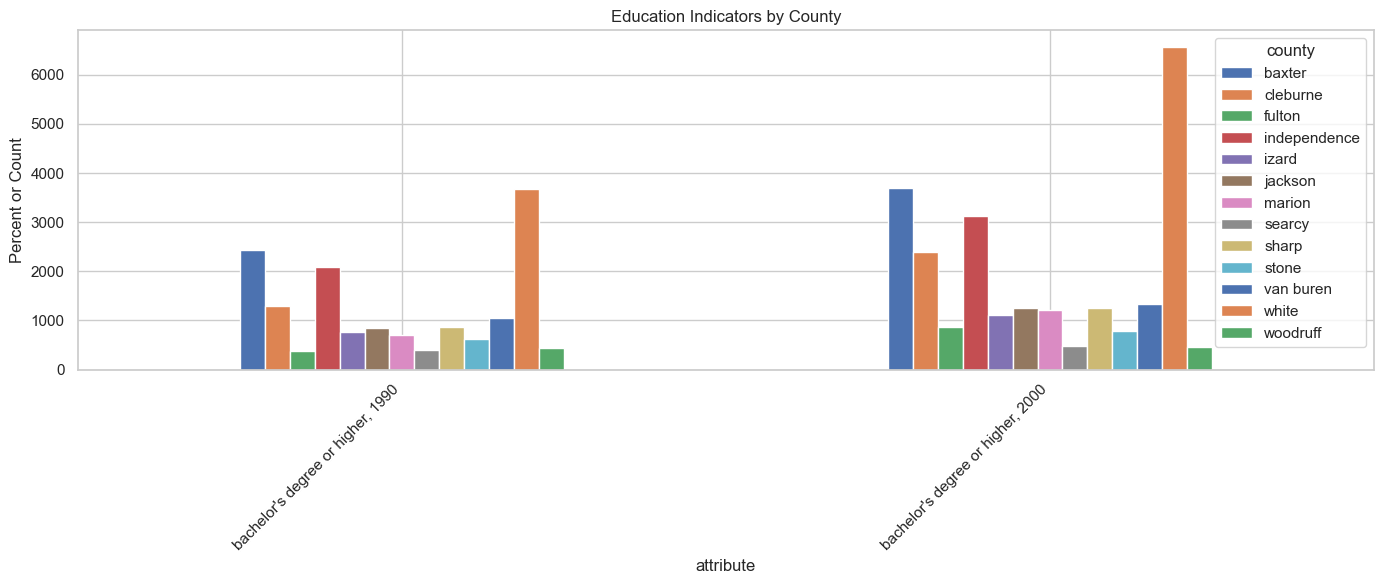

In [49]:
education_cols = used_columns['education'][:2]  # Bachelor's + High School

# Education distribution across counties
title = "Education Indicators by County"
df[education_cols].T.plot(kind='bar', figsize=(14, 6), title=title)
plt.ylabel("Percent or Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Standardize filename
filename = title.lower().replace(" ", "_").replace("’", "").replace("'", "")
plt.savefig(image_dir / f"{filename}.png", dpi=300, bbox_inches='tight')
logging.info(f" Saved: {filename}.png")

plt.show()



### Section 3.4: Distribution Plots (Histograms & KDE)

2025-07-09 17:18:28,263 [INFO] 📷 Saved: distribution_of_povertyrate.png


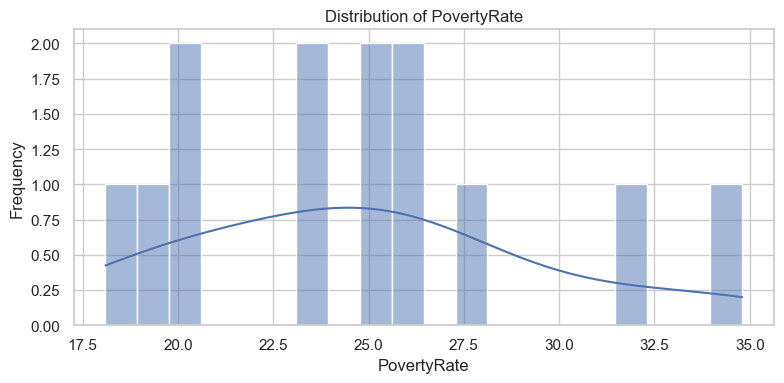

2025-07-09 17:18:28,595 [INFO] 📷 Saved: distribution_of_unemploymentrate.png


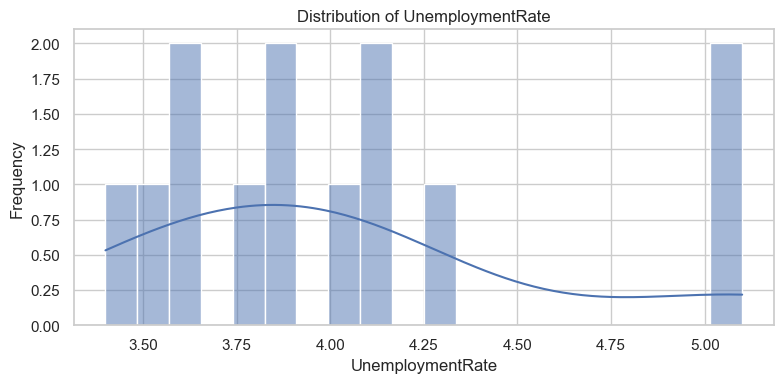

2025-07-09 17:18:28,864 [INFO] 📷 Saved: distribution_of_highschoolgradpct.png


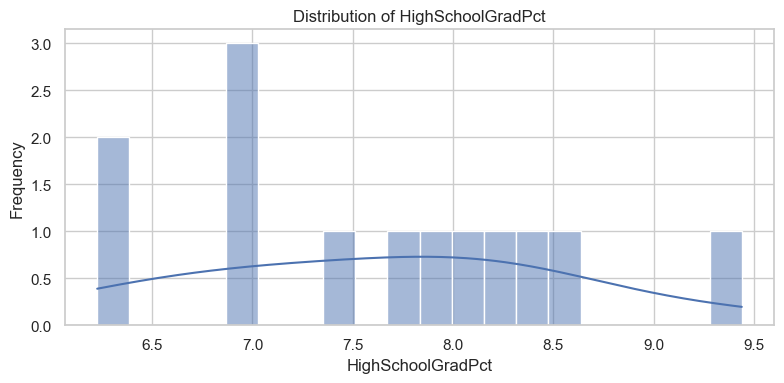

2025-07-09 17:18:29,082 [INFO] 📷 Saved: distribution_of_bachelorsdegreepct.png


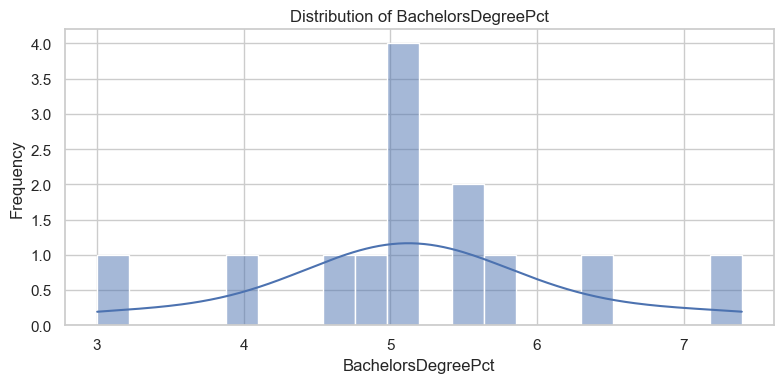

In [54]:
variables = ['PovertyRate', 'UnemploymentRate', 'HighSchoolGradPct', 'BachelorsDegreePct']

for var in variables:
    plt.figure(figsize=(8, 4))
    
    title = f"Distribution of {var}"
    
    # Use the correct DataFrame
    sns.histplot(df_nca[var], kde=True, bins=20)
    
    plt.title(title)
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.tight_layout()
    
    # Save with safe filename
    filename = title.lower().replace(" ", "_").replace("’", "").replace("'", "")
    plt.savefig(image_dir / f"{filename}.png", dpi=300, bbox_inches='tight')
    logging.info(f"📷 Saved: {filename}.png")
    
    plt.show()




### Section 3.5: Correlation Heatmap

In [55]:
# Correlation matrix and heatmap
corr_vars = df[['PovertyRate', 'UnemploymentRate', 'HighSchoolGradRate', 'BachelorsDegreeRate', 'Population']]
corr_matrix = corr_vars.corr()

# Define title
title = "Correlation Between Key Indicators"

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title(title)
plt.tight_layout()

# Generate safe filename from title
filename = title.lower().replace(" ", "_").replace("’", "").replace("'", "")
plt.savefig(image_dir / f"{filename}.png", dpi=300, bbox_inches='tight')
logging.info(f"📷 Saved: {filename}.png")

plt.show()


KeyError: "None of [Index(['PovertyRate', 'UnemploymentRate', 'HighSchoolGradRate',\n       'BachelorsDegreeRate', 'Population'],\n      dtype='object', name='attribute')] are in the [columns]"

### Section 3.6: Key Relationships (Scatter Plots)

In [ ]:
# Scatter Plots of Key Relationships
# 1. Bachelor's Degree vs Poverty
title = "Bachelor's Degree Rate vs. Poverty Rate"
sns.scatterplot(x='BachelorsDegreeRate', y='PovertyRate', data=df)
plt.title(title)
plt.xlabel("Bachelor's Degree (%)")
plt.ylabel("Poverty Rate (%)")
plt.tight_layout()
filename = title.lower().replace(" ", "_").replace("’", "").replace("'", "")
plt.savefig(image_dir / f"{filename}.png", dpi=300, bbox_inches='tight')
logging.info(f"📷 Saved: {filename}.png")
plt.show()

# 2. High School Grad Rate vs Unemployment
title = "High School Grad Rate vs. Unemployment Rate"
sns.scatterplot(x='HighSchoolGradRate', y='UnemploymentRate', data=df)
plt.title(title)
plt.xlabel("High School Grad (%)")
plt.ylabel("Unemployment Rate (%)")
plt.tight_layout()
filename = title.lower().replace(" ", "_").replace("’", "").replace("'", "")
plt.savefig(image_dir / f"{filename}.png", dpi=300, bbox_inches='tight')
logging.info(f"📷 Saved: {filename}.png")
plt.show()

# 3. Population vs Poverty Rate
title = "Population vs. Poverty Rate"
sns.scatterplot(x='Population', y='PovertyRate', data=df)
plt.title(title)
plt.xlabel("Population")
plt.ylabel("Poverty Rate (%)")
plt.tight_layout()
filename = title.lower().replace(" ", "_").replace("’", "").replace("'", "")
plt.savefig(image_dir / f"{filename}.png", dpi=300, bbox_inches='tight')
logging.info(f"📷 Saved: {filename}.png")
plt.show()


### Section 3.7: Outlier Detection with BoxPlots

In [ ]:
# --- Boxplots for Outlier Detection (with title-based save) ---
for var in variables:
    plt.figure(figsize=(8, 4))

    # Define title and filename
    title = f"Boxplot of {var}"
    sns.boxplot(x=df[var])
    plt.title(title)
    plt.tight_layout()

    # Standardize filename
    filename = title.lower().replace(" ", "_").replace("’", "").replace("'", "")
    plt.savefig(image_dir / f"{filename}.png", dpi=300, bbox_inches='tight')
    logging.info(f"📷 Saved: {filename}.png")

    plt.show()


### Section 3.8 ParPlot for Key Indicators

In [ ]:
# Pairplot for Key Indicators
sns.pairplot(df[variables], diag_kind='kde')
plt.suptitle("Pairwise Relationships Between Key Indicators", y=1.02)
plt.tight_layout()
plt.savefig(image_dir / "pairplot_key_indicators.png", dpi=300, bbox_inches='tight')
logging.info("📷 Saved: pairplot_key_indicators.png")
plt.show()


### Step 4: Visualize Distributions (Histograms & KDE)

### Step 5: Correlation Matrix and Heatmap

### Step 6: Scatter Plots for Key Relationships

### Step 7: Identify Outlier Counties with Boxplots

### Step 8: Log-Transform Population (Optional)
If the population is skewed: